# Chronos-2 — Combined RoPE-Fused + Bucketed Group Attention Benchmark

Benchmarks all four model variants side-by-side:

| Model | TimeSelfAttention | GroupSelfAttention |
|---|---|---|
| **Baseline** | Standard MHA (sdpa) | Standard MHA |
| **RoPE-Fused** | Triton-fused kernel | Standard MHA |
| **Bucketed** | Standard MHA (sdpa) | Triton bucketed kernel (auto-selects per group-size bucket) |
| **Combined** | Triton-fused kernel | Triton bucketed kernel |

The bucketed group-attention kernel (`fast_group_attention_transform_pass`) uses `KernelDispatcher` to dispatch one Triton launch per power-of-2 group-size bucket, avoiding the materialisation of a dense attention mask for sparse cross-series interactions.

**Sweeps:**
- **Batch size** ∈ [1, 2, 4, 8, 16, 32, 64, 128, 256] at fixed seq=1024
- **Sequence length** ∈ [128, 256, 512, 1024, 2048] at fixed batch=128
- **GPU memory**: peak transient allocation vs. sequence length and batch size (all 4 variants)
- All sweeps run in **univariate**, **multivariate**, and **mixed** modes

## 1. Imports & Config

In [1]:
import os
import copy
import statistics
import time as _time
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
os.environ.setdefault('HOME', os.environ.get('USERPROFILE', str(Path.home())))

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
OUTPUT_DIR = Path('artifacts/combined_bucketed_benchmark')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Colours — one per model variant
COLORS = {
    'baseline':   '#4C72B0',
    'rope_fused': '#DD8452',
    'bucketed':   '#2ca02c',
    'combined':   '#d62728',
}
MARKERS = {'baseline': 'o', 'rope_fused': 's', 'bucketed': '^', 'combined': 'D'}

print(f'Device     : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU        : {torch.cuda.get_device_name(0)}')
print(f'Output dir : {OUTPUT_DIR}')

Device     : cuda
GPU        : NVIDIA GeForce RTX 5080
Output dir : artifacts/combined_bucketed_benchmark


## 2. Load Chronos-2 Model

In [2]:
from chop.models import get_model
from chop.models.chronos2.triton_rope_attn import is_triton_available as is_rope_triton_available
from chop.models.chronos2.triton_grouped_attn import is_triton_available as is_grouped_triton_available

model = get_model('chronos-2', pretrained=True)
model.eval()
model = model.to(DEVICE)

if hasattr(model.config, '_attn_implementation'):
    model.config._attn_implementation = 'sdpa'
if hasattr(model.config, 'use_cache'):
    model.config.use_cache = False

chronos_cfg = model.config.chronos_config
C_LEN       = chronos_cfg.get('context_length', 8192)
OUT_PATCH   = chronos_cfg.get('output_patch_size', 16)

print(f'Model                  : {type(model).__name__}')
print(f'Context length         : {C_LEN}')
print(f'Output patches         : {OUT_PATCH}')
print(f'Triton RoPE            : {"available ✓" if is_rope_triton_available() else "NOT available (eager fallback)"}')
print(f'Triton grouped-attn    : {"available ✓" if is_grouped_triton_available() else "NOT available (eager fallback)"}')

Model                  : Chronos2Model
Context length         : 8192
Output patches         : 16
Triton RoPE            : available ✓
Triton grouped-attn    : available ✓


## 3. Build Model Variants

Each variant is built from a fresh deep-copy of the baseline model:
- **rope_fused**: `fused_rope_time_attention_transform_pass` — swaps the inner `MHA` of every `TimeSelfAttention` with `RoPEFusedMHA`; RoPE rotation is fused in-register inside the Triton attention kernel
- **bucketed**: `fast_group_attention_transform_pass` — replaces each `GroupSelfAttention` with a `GroupAwareMHA` that dispatches one Triton launch per power-of-2 group-size bucket via `KernelDispatcher`; no dense mask is materialised
- **combined**: both passes applied in sequence

In [3]:
from chop import MaseGraph
from chop.passes.graph import PASSES
from chop.models.chronos2.layers import GroupSelfAttention, TimeSelfAttention
from chop.passes.graph.transforms.timeseries import (
    fused_rope_time_attention_transform_pass,
    fast_group_attention_transform_pass,
)

# ── Trace config — use large batch (256) and short context (64) for fast tracing
TRACE_BATCH = 256
TRACE_SEQ   = 64

trace_in = {
    'context':            torch.randn((TRACE_BATCH, TRACE_SEQ), device=DEVICE),
    'group_ids':          torch.arange(TRACE_BATCH, dtype=torch.long, device=DEVICE),
    'num_output_patches': 1,
}

CUSTOM_OPS = {
    'modules': {
        TimeSelfAttention: {
            'args': {
                'hidden_states':     'data_in',
                'attention_mask':    'data_in',
                'position_ids':      'data_in',
                'output_attentions': 'config',
            }
        },
        GroupSelfAttention: {
            'args': {
                'hidden_states':     'data_in',
                'attention_mask':    'data_in',
                'output_attentions': 'config',
            }
        },
    },
    'functions': {}
}


def _build_mg(base_model: torch.nn.Module) -> MaseGraph:
    """Deep-copy the model, wrap in MaseGraph, and initialise metadata."""
    mg = MaseGraph(
        model=copy.deepcopy(base_model),
        hf_input_names=list(trace_in.keys()),
        custom_ops=CUSTOM_OPS,
    )
    mg, _ = PASSES['init_metadata'](mg)
    # add_value=False: don't store actual tensor values in node metadata.
    # Values are not needed by any transform pass and would pin (TRACE_BATCH *
    # TRACE_SEQ * d_model * num_graph_ops) bytes inside the model for its
    # entire lifetime.
    mg, _ = PASSES['add_common_metadata'](
        mg, pass_args={'dummy_in': trace_in, 'add_value': False}
    )
    return mg


def _attach_attrs(graph_module, src_model):
    """Copy config attributes needed by downstream code and pipelines."""
    for attr in ('config', 'chronos_config', 'device'):
        setattr(graph_module, attr, getattr(src_model, attr))


# group_ids for the pass must be on CPU (GroupPartition reads them at trace time)
bucketed_group_ids = trace_in['group_ids'].cpu()

# ── RoPE-Fused ──────────────────────────────────────────────────────────────
print('Building rope_fused model ...')
mg_rope = _build_mg(model)
mg_rope, rope_info = fused_rope_time_attention_transform_pass(mg_rope)
_attach_attrs(mg_rope.model, model)
print(f'  TimeSelfAttention blocks replaced: {rope_info["replaced"]}')

# ── Bucketed group attention ─────────────────────────────────────────────────
print('Building bucketed model ...')
mg_bucketed = _build_mg(model)
mg_bucketed, bucketed_info = fast_group_attention_transform_pass(
    mg_bucketed, pass_args={'group_ids': bucketed_group_ids}
)
_attach_attrs(mg_bucketed.model, model)
print(f'  GroupSelfAttention blocks transformed: {bucketed_info.get("replaced", "?")}')

# ── Combined ────────────────────────────────────────────────────────────────
print('Building combined model ...')
mg_combined = _build_mg(model)
mg_combined, _ = fused_rope_time_attention_transform_pass(mg_combined)
mg_combined, _ = fast_group_attention_transform_pass(
    mg_combined, pass_args={'group_ids': bucketed_group_ids}
)
_attach_attrs(mg_combined.model, model)
print('  Both transforms applied')

# ── Model registry ──────────────────────────────────────────────────────────
MODELS = {
    'baseline':   model,
    'rope_fused': mg_rope.model,
    'bucketed':   mg_bucketed.model,
    'combined':   mg_combined.model,
}

print('\nAll variants ready:', list(MODELS.keys()))


W0326 12:26:12.643000 961 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


Building rope_fused model ...
tensor([[ 0.4984,  0.3398, -0.7221,  ..., -0.5458, -1.9731,  1.0703],
        [-1.8343, -0.2231, -0.2750,  ..., -1.7004,  0.1538,  0.7978],
        [-0.3710, -0.9863,  1.9015,  ..., -0.8618, -0.3916,  0.9577],
        ...,
        [-0.7490,  0.5829,  1.2250,  ...,  1.0074, -0.8069,  1.9120],
        [ 1.9704,  0.5185, -0.7047,  ...,  0.1042,  0.2942,  1.6023],
        [ 0.1148, -0.0460, -0.7744,  ...,  1.8811, -0.3646,  0.3787]], device='cuda:0')
tensor([[ 0.4984,  0.3398, -0.7221,  ..., -0.5458, -1.9731,  1.0703],
        [-1.8343, -0.2231, -0.2750,  ..., -1.7004,  0.1538,  0.7978],
        [-0.3710, -0.9863,  1.9015,  ..., -0.8618, -0.3916,  0.9577],
        ...,
        [-0.7490,  0.5829,  1.2250,  ...,  1.0074, -0.8069,  1.9120],
        [ 1.9704,  0.5185, -0.7047,  ...,  0.1042,  0.2942,  1.6023],
        [ 0.1148, -0.0460, -0.7744,  ...,  1.8811, -0.3646,  0.3787]], device='cuda:0')
tensor([[False, False, False,  ..., False, False, False],
        [F

## 4. Numerical Sanity Check

All variants must produce `quantile_preds` close to the baseline (atol=5e-2).

In [4]:
from chop.models.chronos2.modeling_chronos2 import Chronos2Output

_CHECK_BATCH = 8
_CHECK_SEQ   = 128
_ctx  = torch.randn(_CHECK_BATCH, _CHECK_SEQ, device=DEVICE)
_gids = torch.arange(_CHECK_BATCH, dtype=torch.long, device=DEVICE)


def _get_preds(m, ctx, gids):
    result = m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)
    if isinstance(result, dict):
        return result['quantile_preds'].float()
    return result.quantile_preds.float()


with torch.no_grad():
    base_preds = _get_preds(model, _ctx, _gids)
    for name, m in list(MODELS.items())[1:]:
        preds    = _get_preds(m, _ctx, _gids)
        max_diff = (base_preds - preds).abs().max().item()
        close    = torch.allclose(base_preds, preds, atol=5e-2, rtol=5e-2)
        status   = '✓' if close else '✗'
        print(f'{status} {name:<12}  max_diff = {max_diff:.2e}')

✓ rope_fused    max_diff = 3.83e-03
✓ bucketed      max_diff = 0.00e+00
✓ combined      max_diff = 3.83e-03


## 5. Benchmark Utilities

In [5]:
_DEVICE_OBJ = torch.device(DEVICE)


def benchmark_fn(fn, warmup: int = 3, iters: int = 5) -> float:
    """Return median latency in milliseconds."""
    use_cuda = _DEVICE_OBJ.type == 'cuda'
    if use_cuda:
        start_ev = torch.cuda.Event(enable_timing=True)
        end_ev   = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for _ in range(warmup):
            fn()
        if use_cuda:
            torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for _ in range(iters):
            if use_cuda:
                start_ev.record()
                fn()
                end_ev.record()
                torch.cuda.synchronize()
                times.append(start_ev.elapsed_time(end_ev))
            else:
                t0 = _time.perf_counter()
                fn()
                times.append((_time.perf_counter() - t0) * 1e3)

    return statistics.median(times)


def measure_peak_memory(fn, warmup: int = 1) -> dict:
    """Return peak *transient* allocated bytes above the static model baseline."""
    if not torch.cuda.is_available():
        return {'transient': float('nan')}

    with torch.no_grad():
        for _ in range(warmup):
            fn()
        torch.cuda.synchronize()
        static_base = torch.cuda.memory_allocated()
        torch.cuda.reset_peak_memory_stats()
        fn()
        torch.cuda.synchronize()

    return {'transient': torch.cuda.max_memory_allocated() - static_base}


def fmt_mb(n: float) -> str:
    return f'{n / 1024**2:.1f} MB'


print('Benchmark utilities ready.')

Benchmark utilities ready.


In [6]:
import gc

import contextlib
import sys
import os

@contextlib.contextmanager
def total_silence():
    """
    1. Overrides Tensor __repr__ to prevent OOM.
    2. Redirects stdout to devnull to stop the wall of text.
    """
    original_repr = torch.Tensor.__repr__
    original_str = torch.Tensor.__str__
    
    def dummy_repr(self, *args, **kwargs):
        return "" # Return empty to save even more string overhead
        
    torch.Tensor.__repr__ = dummy_repr
    torch.Tensor.__str__ = dummy_repr
    
    # Redirect stdout to the system's "null" device
    with open(os.devnull, 'w') as devnull:
        with contextlib.redirect_stdout(devnull):
            try:
                yield
            finally:
                torch.Tensor.__repr__ = original_repr
                torch.Tensor.__str__ = original_str

import gc

def retransform_graph_models(base_model, bs, gids_cpu, device):
    # Explicitly delete old transformed models before allocating new ones so
    # their GPU tensors (including activations stored in node metadata by
    # add_common_metadata) are freed before the new models are built.
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Use TRACE_SEQ (small, fixed) here — the group partition depends only on
    # the batch dimension (gids_cpu).  Using the full sweep seq would run a
    # real forward pass at (bs, sweep_seq) inside add_common_metadata, which
    # is both slow and causes large activation tensors to be stored in node
    # metadata.
    current_trace_in = {
        'context':            torch.randn((bs, TRACE_SEQ), device=device),
        'group_ids':          gids_cpu.to(device),
        'num_output_patches': 1,
    }

    def _build_local_mg(model_to_wrap):
        mg = MaseGraph(
            model=copy.deepcopy(model_to_wrap),
            hf_input_names=list(current_trace_in.keys()),
            custom_ops=CUSTOM_OPS,
        )
        mg, _ = PASSES['init_metadata'](mg)
        # add_value=False: skip storing actual tensor values in node metadata.
        # We only need shapes for the transform passes; storing values would
        # pin (bs * TRACE_SEQ * d_model * num_ops) bytes inside every node's
        # meta dict for the lifetime of the returned model.
        mg, _ = PASSES['add_common_metadata'](
            mg, pass_args={'dummy_in': current_trace_in, 'add_value': False}
        )
        return mg

    # Wrap the heavy tracing operations in the silencer
    with total_silence():
        # Build Bucketed
        mg_bucketed = _build_local_mg(base_model)
        mg_bucketed, _ = fast_group_attention_transform_pass(
            mg_bucketed, pass_args={'group_ids': gids_cpu}
        )
        _attach_attrs(mg_bucketed.model, base_model)
        mg_bucketed.model.eval()

        # Build Combined
        mg_combined = _build_local_mg(base_model)
        mg_combined, _ = fused_rope_time_attention_transform_pass(mg_combined)
        mg_combined, _ = fast_group_attention_transform_pass(
            mg_combined, pass_args={'group_ids': gids_cpu}
        )
        _attach_attrs(mg_combined.model, base_model)
        mg_combined.model.eval()

    return mg_bucketed.model, mg_combined.model


## 6. Batch Size Sweep

Fixed context length = 1024.  
Batch sizes: `[1, 2, 4, 8, 16, 32, 64, 128, 256]`  
Tested in **univariate** (`group_ids = arange`), **multivariate** (`group_ids = zeros`), and **mixed** (half-half) modes.

In [ ]:
BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
SWEEP_SEQ   = 1024
WARMUP      = 3
ITERS       = 5

model_names = list(MODELS.keys())

VARIATE_MODES = ['univariate', 'multivariate', 'mixed']

batch_results = {
    mode: {name: [] for name in model_names}
    for mode in VARIATE_MODES
}

header = f"{'Batch':>6} | " + " | ".join(f"{n:>12}" for n in model_names)

for mode in VARIATE_MODES:
    print(f"\n{'═'*70}")
    print(f"Batch size sweep — {mode:>14}   (seq={SWEEP_SEQ})")
    print(f"{'═'*70}")
    print(header)
    print('-' * len(header))

    for bs in BATCH_SIZES:
        ctx = torch.randn(bs, SWEEP_SEQ, device=DEVICE)
        if mode == 'univariate':
            gids = torch.arange(bs, dtype=torch.long, device=DEVICE)
        elif mode == 'multivariate':
            gids = torch.zeros(bs, dtype=torch.long, device=DEVICE)
        else:  # mixed
            half = max(1, bs // 2)
            gids = torch.cat([
                torch.zeros(half, dtype=torch.long),
                torch.ones(bs - half, dtype=torch.long),
            ]).to(DEVICE)

        gids_cpu = gids.cpu()

        # Explicitly release old transformed models before building new ones so
        # their GPU tensors (metadata activations + weights) are freed first.
        del MODELS['bucketed'], MODELS['combined']
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        # Retransform for this batch size (seq arg removed — retransform uses TRACE_SEQ internally)
        MODELS['bucketed'], MODELS['combined'] = retransform_graph_models(
            base_model=MODELS['baseline'],
            bs=bs,
            gids_cpu=gids_cpu,
            device=DEVICE
        )

        row = [f'{bs:>6}']
        for name, m in MODELS.items():
            def _run(m=m, ctx=ctx, gids=gids):
                m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)

            t = benchmark_fn(_run, warmup=WARMUP, iters=ITERS)
            batch_results[mode][name].append(t)
            row.append(f'{t:>11.2f}ms')

        base_t = batch_results[mode]['baseline'][-1]
        speedups = [
            f'  {base_t / batch_results[mode][n][-1]:.2f}x ({n[:3]})'
            for n in model_names if n != 'baseline'
        ]
        print(' | '.join(row) + '   ' + '  '.join(speedups))

        torch.cuda.empty_cache() if torch.cuda.is_available() else None



══════════════════════════════════════════════════════════════════════
Batch size sweep —     univariate   (seq=1024)
══════════════════════════════════════════════════════════════════════
 Batch |     baseline |   rope_fused |     bucketed |     combined
------------------------------------------------------------------
     1 |       13.60ms |       11.39ms |       12.04ms |        9.74ms     1.19x (rop)    1.13x (buc)    1.40x (com)
     2 |       15.03ms |       12.08ms |       14.16ms |       12.23ms     1.24x (rop)    1.06x (buc)    1.23x (com)
     4 |       14.84ms |       21.86ms |       12.39ms |        9.53ms     0.68x (rop)    1.20x (buc)    1.56x (com)
     8 |       14.82ms |       12.16ms |       12.72ms |       10.64ms     1.22x (rop)    1.17x (buc)    1.39x (com)
    16 |       19.46ms |       18.14ms |       16.67ms |       15.42ms     1.07x (rop)    1.17x (buc)    1.26x (com)
    32 |       30.19ms |       29.68ms |       26.46ms |       24.25ms     1.02x (rop)    1

## 7. Sequence Length Sweep

Fixed batch size = 128.  
Sequence lengths: `[128, 256, 512, 1024, 2048]`  
Tested in **univariate**, **multivariate**, and **mixed** modes.

In [10]:
SEQ_LENS    = [128, 256, 512, 1024, 2048]
FIXED_BATCH = 128

seq_results = {
    mode: {name: [] for name in model_names}
    for mode in VARIATE_MODES
}

header_seq = f"{'SeqLen':>7} | " + " | ".join(f"{n:>12}" for n in model_names)

for mode in VARIATE_MODES:
    if mode == 'univariate':
        gids = torch.arange(FIXED_BATCH, dtype=torch.long, device=DEVICE)
    elif mode == 'multivariate':
        gids = torch.zeros(FIXED_BATCH, dtype=torch.long, device=DEVICE)
    else:  # mixed
        half = FIXED_BATCH // 2
        gids = torch.cat([
            torch.zeros(half, dtype=torch.long),
            torch.ones(FIXED_BATCH - half, dtype=torch.long),
        ]).to(DEVICE)

    # Retransform once per mode — partition depends only on batch structure,
    # not on seq length, so a single retransform covers the whole seq sweep.
    del MODELS['bucketed'], MODELS['combined']
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    MODELS['bucketed'], MODELS['combined'] = retransform_graph_models(
        base_model=MODELS['baseline'],
        bs=FIXED_BATCH,
        gids_cpu=gids.cpu(),
        device=DEVICE
    )

    print(f"\nSequence length sweep — {mode}   (batch={FIXED_BATCH})")
    print('═' * len(header_seq))
    print(header_seq)
    print('-' * len(header_seq))

    for seq in SEQ_LENS:
        ctx = torch.randn(FIXED_BATCH, seq, device=DEVICE)

        row = [f'{seq:>7}']
        for name, m in MODELS.items():
            def _run(m=m, ctx=ctx, gids=gids):
                m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)

            t = benchmark_fn(_run, warmup=WARMUP, iters=ITERS)
            seq_results[mode][name].append(t)
            row.append(f'{t:>11.2f}ms')

        base_t = seq_results[mode]['baseline'][-1]
        speedups = [
            f'  {base_t / seq_results[mode][n][-1]:.2f}x ({n[:3]})'
            for n in model_names if n != 'baseline'
        ]
        print(' | '.join(row) + '   ' + '  '.join(speedups))

        torch.cuda.empty_cache() if torch.cuda.is_available() else None



Sequence length sweep — univariate   (batch=128)
═══════════════════════════════════════════════════════════════════
 SeqLen |     baseline |   rope_fused |     bucketed |     combined
-------------------------------------------------------------------
    128 |       38.17ms |       36.30ms |       31.60ms |       29.58ms     1.05x (rop)    1.21x (buc)    1.29x (com)
    256 |       51.15ms |       49.63ms |       42.12ms |       40.66ms     1.03x (rop)    1.21x (buc)    1.26x (com)
    512 |       72.51ms |       68.57ms |       59.60ms |       55.56ms     1.06x (rop)    1.22x (buc)    1.31x (com)
   1024 |      123.40ms |      114.02ms |      100.92ms |       94.99ms     1.08x (rop)    1.22x (buc)    1.30x (com)
   2048 |      262.14ms |      235.30ms |      212.29ms |      188.83ms     1.11x (rop)    1.23x (buc)    1.39x (com)

Sequence length sweep — multivariate   (batch=128)
═══════════════════════════════════════════════════════════════════
 SeqLen |     baseline |   rope_fuse

## 8. Scaling Visualization

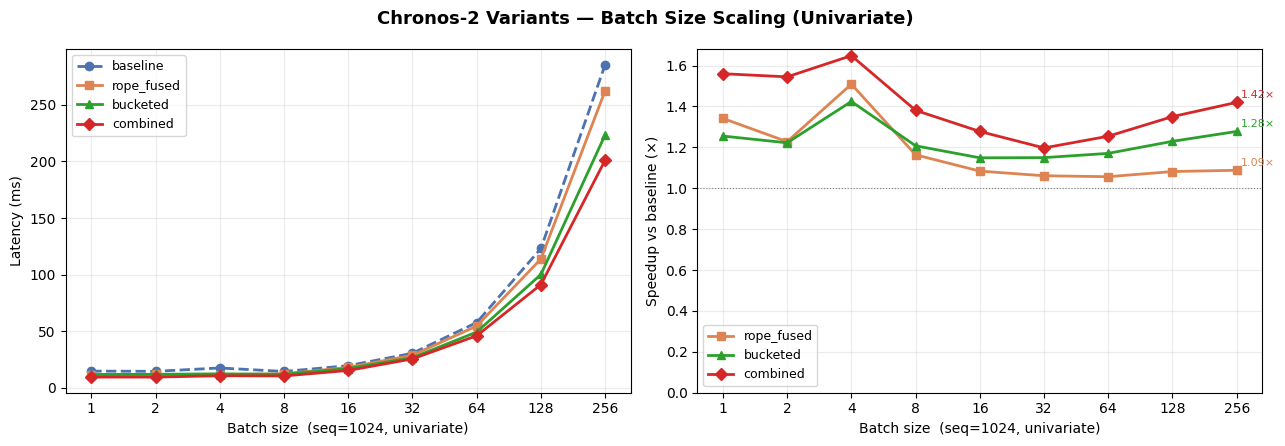

Saved → artifacts/combined_bucketed_benchmark/scaling_batch_univariate.png


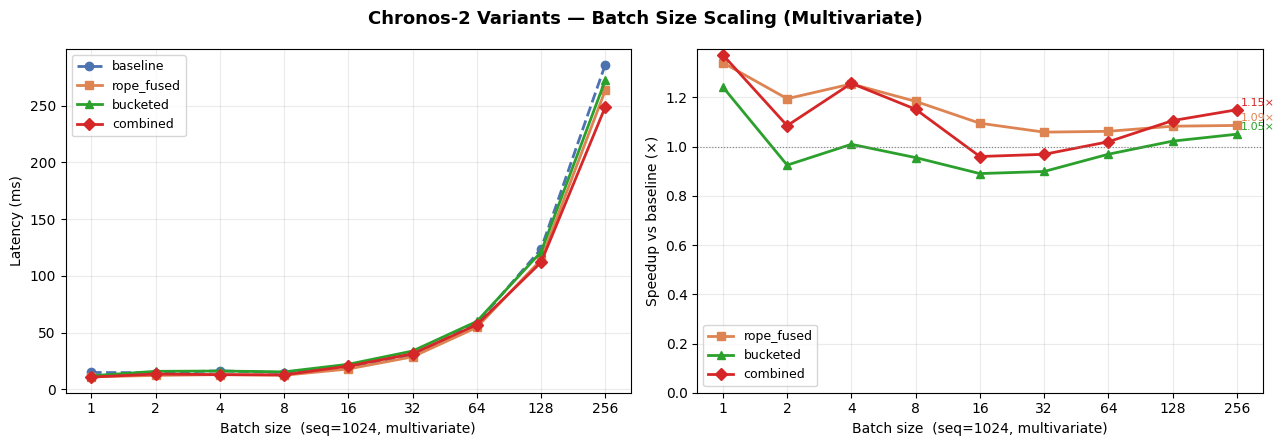

Saved → artifacts/combined_bucketed_benchmark/scaling_batch_multivariate.png


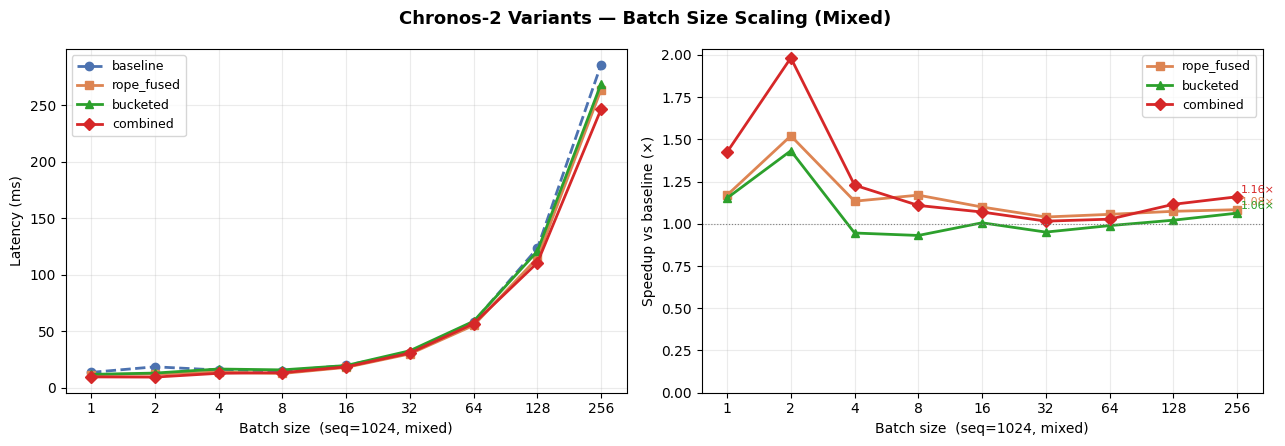

Saved → artifacts/combined_bucketed_benchmark/scaling_batch_mixed.png


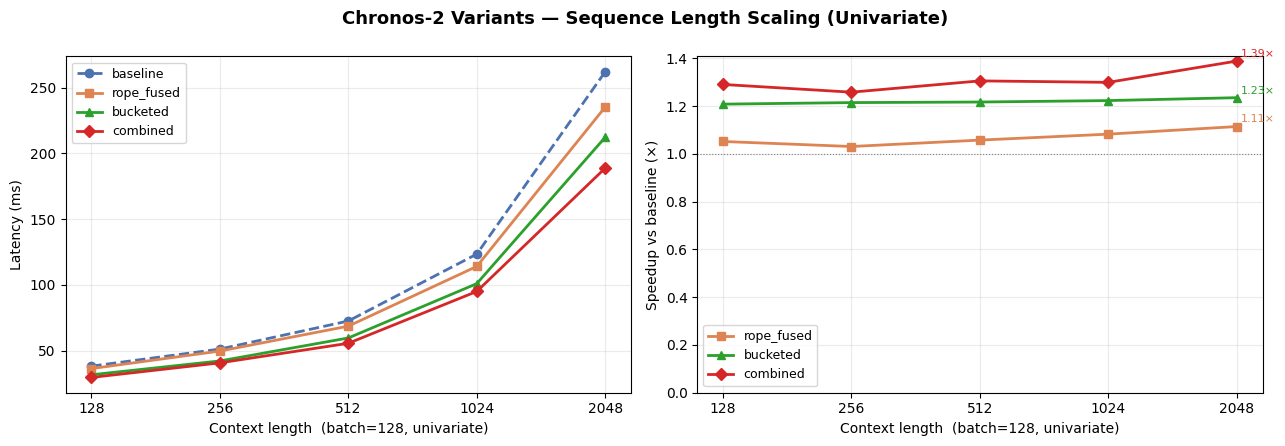

Saved → artifacts/combined_bucketed_benchmark/scaling_seq_univariate.png


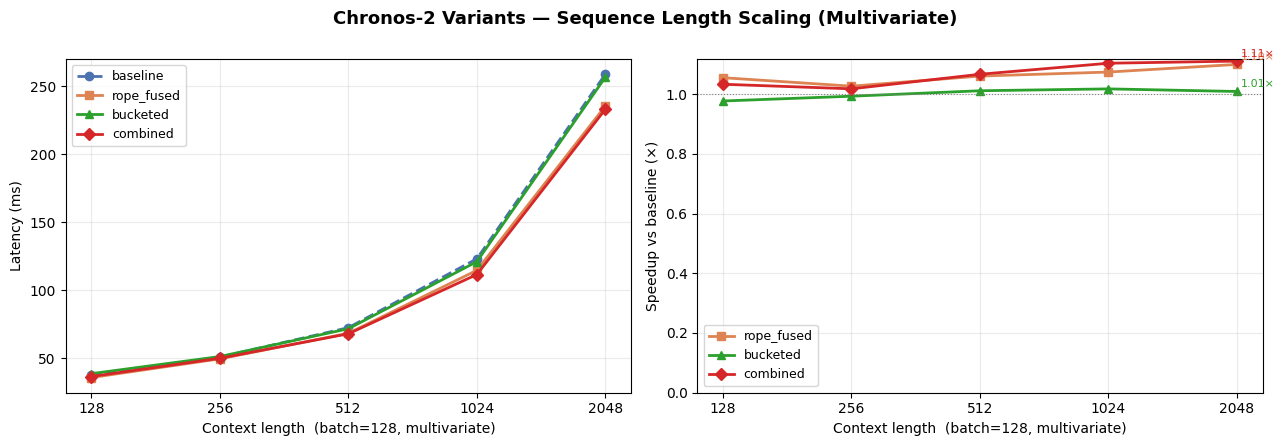

Saved → artifacts/combined_bucketed_benchmark/scaling_seq_multivariate.png


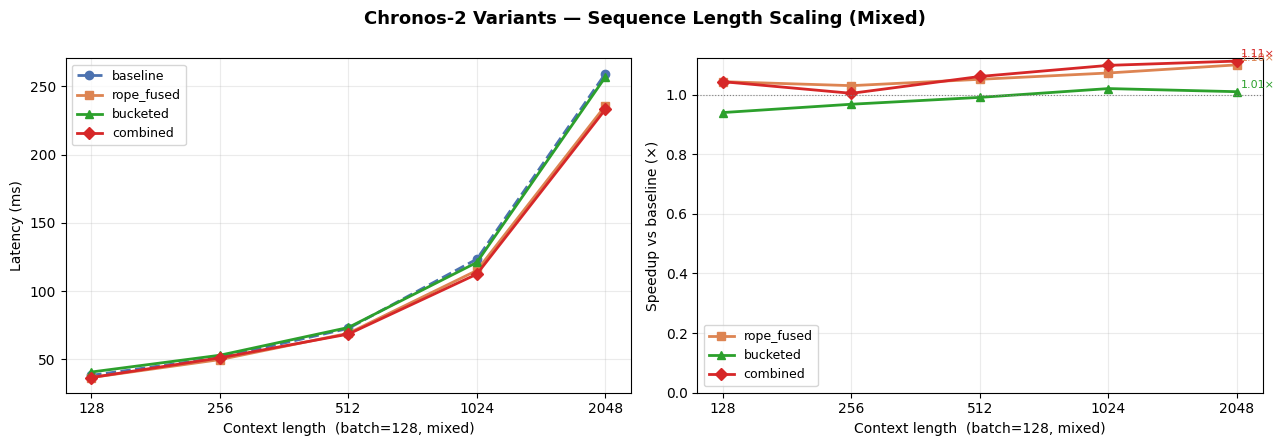

Saved → artifacts/combined_bucketed_benchmark/scaling_seq_mixed.png


In [11]:
def _plot_sweep(x_vals, results_dict, x_label, title, save_path,
                speedup_ref='baseline', vline=None, vline_label=None):
    """Two-panel figure: (left) absolute latency, (right) speedup vs baseline."""
    fig, (ax_lat, ax_su) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    base_ms = np.array(results_dict[speedup_ref])

    for name in model_names:
        ms      = np.array(results_dict[name])
        speedup = base_ms / ms
        ls      = '--' if name == 'baseline' else '-'
        ax_lat.plot(x_vals, ms,      marker=MARKERS[name], ls=ls, color=COLORS[name], lw=2.0, label=name)
        if name != speedup_ref:
            ax_su.plot(x_vals, speedup, marker=MARKERS[name], ls='-', color=COLORS[name], lw=2.0, label=name)
            ax_su.annotate(f'{speedup[-1]:.2f}×',
                           xy=(x_vals[-1], speedup[-1]),
                           xytext=(3, 3), textcoords='offset points',
                           fontsize=8, color=COLORS[name])

    ax_su.axhline(1.0, color='grey', lw=0.8, ls=':')
    if vline is not None:
        for ax in (ax_lat, ax_su):
            ax.axvline(vline, color='#d62728', lw=1.5, ls=':', label=vline_label or str(vline))

    for ax, ylabel in ((ax_lat, 'Latency (ms)'), (ax_su, 'Speedup vs baseline (×)')):
        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_xscale('log', base=2)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())
        ax.set_xticks(x_vals)
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=9)

    ax_su.set_ylim(bottom=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


# Batch sweep — all variate modes
for mode in VARIATE_MODES:
    _plot_sweep(
        BATCH_SIZES, batch_results[mode],
        x_label=f'Batch size  (seq={SWEEP_SEQ}, {mode})',
        title=f'Chronos-2 Variants — Batch Size Scaling ({mode.capitalize()})',
        save_path=OUTPUT_DIR / f'scaling_batch_{mode}.png',
    )

# Sequence length sweep — all variate modes
for mode in VARIATE_MODES:
    _plot_sweep(
        SEQ_LENS, seq_results[mode],
        x_label=f'Context length  (batch={FIXED_BATCH}, {mode})',
        title=f'Chronos-2 Variants — Sequence Length Scaling ({mode.capitalize()})',
        save_path=OUTPUT_DIR / f'scaling_seq_{mode}.png',
    )


## 9. GPU Memory Analysis

Measures **peak transient** allocated bytes above the static model weight baseline during a single forward pass.

Two sweeps:
- **Seq-length sweep** at fixed batch = 4
- **Batch-size sweep** at fixed seq = 1024

In [ ]:
SEQ_LENS_MEM    = [128, 256, 512, 1024, 2048]
FIXED_BATCH_MEM = 4

mem_seq = {mode: {name: [] for name in model_names} for mode in VARIATE_MODES}

for mode in VARIATE_MODES:
    if mode == 'univariate':
        _gids_mem = torch.arange(FIXED_BATCH_MEM, dtype=torch.long, device=DEVICE)
    elif mode == 'multivariate':
        _gids_mem = torch.zeros(FIXED_BATCH_MEM, dtype=torch.long, device=DEVICE)
    else:  # mixed
        half = FIXED_BATCH_MEM // 2
        _gids_mem = torch.cat([
            torch.zeros(half, dtype=torch.long),
            torch.ones(FIXED_BATCH_MEM - half, dtype=torch.long),
        ]).to(DEVICE)

    print(f'\nPeak transient memory — seq sweep  (batch={FIXED_BATCH_MEM}, {mode})')
    print(f"{'SeqLen':>7}  " + "  ".join(f"{n:>14}" for n in model_names))
    print('-' * 72)

    for seq in SEQ_LENS_MEM:
        ctx = torch.randn(FIXED_BATCH_MEM, seq, device=DEVICE)
        row = [f'{seq:>7}']
        for name, m in MODELS.items():
            gids_cap = _gids_mem
            def _fwd(m=m, ctx=ctx, gids=gids_cap): m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)
            mem = measure_peak_memory(_fwd)['transient']
            mem_seq[mode][name].append(mem)
            row.append(f'{fmt_mb(mem):>14}')
        print('  '.join(row))


In [ ]:
BATCH_SIZES_MEM = [1, 2, 4, 8, 16, 32, 64, 128, 256]
FIXED_SEQ_MEM   = 1024

mem_batch = {mode: {name: [] for name in model_names} for mode in VARIATE_MODES}

for mode in VARIATE_MODES:
    print(f'\nPeak transient memory — batch sweep  (seq={FIXED_SEQ_MEM}, {mode})')
    print(f"{'Batch':>6}  " + "  ".join(f"{n:>14}" for n in model_names))
    print('-' * 72)

    for bs in BATCH_SIZES_MEM:
        ctx = torch.randn(bs, FIXED_SEQ_MEM, device=DEVICE)
        if mode == 'univariate':
            gids = torch.arange(bs, dtype=torch.long, device=DEVICE)
        elif mode == 'multivariate':
            gids = torch.zeros(bs, dtype=torch.long, device=DEVICE)
        else:  # mixed
            half = max(1, bs // 2)
            gids = torch.cat([
                torch.zeros(half, dtype=torch.long),
                torch.ones(bs - half, dtype=torch.long),
            ]).to(DEVICE)

        row = [f'{bs:>6}']
        for name, m in MODELS.items():
            gids_cap = gids
            def _fwd(m=m, ctx=ctx, gids=gids_cap): m(context=ctx, group_ids=gids, num_output_patches=OUT_PATCH)
            mem = measure_peak_memory(_fwd)['transient']
            mem_batch[mode][name].append(mem)
            row.append(f'{fmt_mb(mem):>14}')
        print('  '.join(row))
        torch.cuda.empty_cache() if torch.cuda.is_available() else None


In [ ]:
def _plot_memory(x_vals, mem_dict, x_label, title, save_path):
    fig, (ax_abs, ax_save) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    base_mb = np.array(mem_dict['baseline']) / 1024**2

    for name in model_names:
        mb = np.array(mem_dict[name]) / 1024**2
        ls = '--' if name == 'baseline' else '-'
        ax_abs.plot(x_vals, mb, marker=MARKERS[name], ls=ls, color=COLORS[name], lw=2.0, label=name)

    ax_abs.set_xlabel(x_label, fontsize=10)
    ax_abs.set_ylabel('Transient allocated (MB)', fontsize=10)
    ax_abs.set_xscale('log', base=2)
    ax_abs.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax_abs.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax_abs.set_xticks(x_vals)
    ax_abs.legend(fontsize=9)
    ax_abs.grid(True, alpha=0.25)

    # Savings relative to baseline
    for name in model_names:
        if name == 'baseline':
            continue
        mb    = np.array(mem_dict[name]) / 1024**2
        saved = np.where(base_mb > 0, 100.0 * (base_mb - mb) / base_mb, 0.0)
        ax_save.plot(x_vals, saved, marker=MARKERS[name], ls='-', color=COLORS[name], lw=2.0, label=name)
        ax_save.annotate(f'{saved[-1]:.1f}%',
                         xy=(x_vals[-1], saved[-1]),
                         xytext=(3, 2), textcoords='offset points',
                         fontsize=8, color=COLORS[name])

    ax_save.axhline(0, color='grey', lw=0.8, ls=':')
    ax_save.set_xlabel(x_label, fontsize=10)
    ax_save.set_ylabel('Memory saved vs baseline (%)', fontsize=10)
    ax_save.set_xscale('log', base=2)
    ax_save.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax_save.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax_save.set_xticks(x_vals)
    ax_save.legend(fontsize=9)
    ax_save.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


# Memory — seq sweep — all variate modes
for mode in VARIATE_MODES:
    _plot_memory(
        SEQ_LENS_MEM, mem_seq[mode],
        x_label=f'Context length  (batch={FIXED_BATCH_MEM}, {mode})',
        title=f'Peak Transient GPU Memory vs Context Length ({mode.capitalize()})',
        save_path=OUTPUT_DIR / f'memory_seq_{mode}.png',
    )

# Memory — batch sweep — all variate modes
for mode in VARIATE_MODES:
    _plot_memory(
        BATCH_SIZES_MEM, mem_batch[mode],
        x_label=f'Batch size  (seq={FIXED_SEQ_MEM}, {mode})',
        title=f'Peak Transient GPU Memory vs Batch Size ({mode.capitalize()})',
        save_path=OUTPUT_DIR / f'memory_batch_{mode}.png',
    )


## 10. Summary

In [ ]:
import pandas as pd

# ── Latency speedup table for each variate mode — batch sweep ───────────────
for mode in VARIATE_MODES:
    print(f'\nSpeedup vs baseline — batch sweep, {mode}, seq={SWEEP_SEQ}')
    rows = []
    for i, bs in enumerate(BATCH_SIZES):
        base_t = batch_results[mode]['baseline'][i]
        row = {'batch': bs}
        for name in model_names:
            if name != 'baseline':
                row[f'{name}_speedup'] = round(base_t / batch_results[mode][name][i], 3)
        rows.append(row)
    df = pd.DataFrame(rows).set_index('batch')
    print(df.to_string())

# ── Latency speedup table for each variate mode — seq sweep ─────────────────
for mode in VARIATE_MODES:
    print(f'\nSpeedup vs baseline — seq sweep, {mode}, batch={FIXED_BATCH}')
    rows = []
    for i, seq in enumerate(SEQ_LENS):
        base_t = seq_results[mode]['baseline'][i]
        row = {'seq': seq}
        for name in model_names:
            if name != 'baseline':
                row[f'{name}_speedup'] = round(base_t / seq_results[mode][name][i], 3)
        rows.append(row)
    df = pd.DataFrame(rows).set_index('seq')
    print(df.to_string())

# ── Memory savings at largest seq ────────────────────────────────────────────
print(f'\nPeak transient memory @ seq={SEQ_LENS_MEM[-1]}, batch={FIXED_BATCH_MEM}')
for mode in VARIATE_MODES:
    base_mem = mem_seq[mode]['baseline'][-1]
    print(f'\n  {mode}:')
    print(f"    baseline   : {fmt_mb(base_mem)}")
    for name in model_names:
        if name == 'baseline':
            continue
        m   = mem_seq[mode][name][-1]
        pct = 100 * (base_mem - m) / base_mem if base_mem > 0 else float('nan')
        print(f'    {name:<12}: {fmt_mb(m)}   ({pct:+.1f}% vs baseline)')

# ── Save plots list ──────────────────────────────────────────────────────────
print(f'\nPlots saved to {OUTPUT_DIR}/')
for p in sorted(OUTPUT_DIR.glob('*.png')):
    print(f'  {p.name}')
